# TP Optimisation Sans Contrainte — Fonction de Rosenbrock

### Étudiant : KOUTSAVA Kossi Epiphane
### Charge du cours : Dr PINDRA

**Objectif :** Implémenter la descente de gradient et la méthode de Newton pour l'optimisation sans contrainte, et comparer leur convergence ainsi que leur temps de calcul.

---

## Problème posé

On cherche à minimiser la **fonction de Rosenbrock** :

$$\min_{\theta \in \mathbb{R}^2} J(\theta) \quad \text{avec} \quad J(\theta) = (1 - \theta_1)^2 + 100\left(\theta_2 - \theta_1^2\right)^2$$

Cette fonction est un classique en optimisation numérique : elle possède une **vallée en forme de banane** très courbée, ce qui la rend difficile à minimiser pour les algorithmes du premier ordre (gradient). Son minimum global est en $\theta^* = (1, 1)^T$ avec $J(\theta^*) = 0$.

---


## 0. Importation des bibliothèques

On importe les bibliothèques classiques de calcul scientifique Python.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import norm, solve
import time

# Affichage inline des graphiques
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 13


---
# Partie 1 — Analyse théorique

## 1.1 Détermination du point stationnaire $\theta^*$

Un point stationnaire vérifie $\nabla_\theta J(\theta^*) = 0$.

**Calcul du gradient :**

On dérive $J(\theta) = (1 - \theta_1)^2 + 100(\theta_2 - \theta_1^2)^2$ :

$$\frac{\partial J}{\partial \theta_1} = -2(1 - \theta_1) - 400\,\theta_1(\theta_2 - \theta_1^2)$$

$$\frac{\partial J}{\partial \theta_2} = 200(\theta_2 - \theta_1^2)$$

**Résolution de $\nabla_\theta J(\theta^*) = 0$ :**

- Depuis $\frac{\partial J}{\partial \theta_2} = 0$ : $\quad \theta_2 = \theta_1^2$
- En substituant dans $\frac{\partial J}{\partial \theta_1} = 0$ : $\quad -2(1 - \theta_1) = 0 \Rightarrow \theta_1 = 1$
- Donc : $\theta_2 = 1$

$$\boxed{\theta^* = (1,\ 1)^T}$$

---

## 1.2 Vérification que $\theta^*$ est un minimum (Hessienne)

La matrice Hessienne est :

$$H(\theta) = \begin{pmatrix} 2 - 400\theta_2 + 1200\theta_1^2 & -400\theta_1 \\ -400\theta_1 & 200 \end{pmatrix}$$

En $\theta^* = (1, 1)$ :

$$H(\theta^*) = \begin{pmatrix} 802 & -400 \\ -400 & 200 \end{pmatrix}$$

**Critère de Sylvester (définie positivité) :**
- Mineur d'ordre 1 : $802 > 0$ ✓
- Déterminant : $802 \times 200 - 400^2 = 160400 - 160000 = 400 > 0$ ✓

La Hessienne en $\theta^*$ est **définie positive** : $\theta^* = (1,1)^T$ est bien un **minimum** de $J$.

> **Remarque importante :** La fonction de Rosenbrock n'est pas convexe globalement. La Hessienne n'est définie positive qu'au voisinage de $\theta^*$. C'est pourquoi les algorithmes d'optimisation peuvent rencontrer des difficultés loin du minimum.


---
# Partie 2 — Implémentation des algorithmes

## 2.1 Fonctions de base : critère, gradient, hessienne

Avant d'implémenter les algorithmes, on définit les trois briques fondamentales :
- `mycriterion` : calcule $J(\theta)$
- `mygradient` : calcule $\nabla_\theta J(\theta)$ analytiquement
- `myhessian` : calcule $H(\theta)$ analytiquement

L'utilisation du gradient **analytique** (et non numérique) est cruciale : elle évite les erreurs d'approximation par différences finies et accélère le calcul.


In [2]:
# ──────────────────────────────────────────────────────────
# Critère de Rosenbrock  J(theta)
# ──────────────────────────────────────────────────────────
def mycriterion(theta):
    """
    Calcule la valeur de la fonction de Rosenbrock.
    Entrée  : theta — vecteur numpy de taille 2
    Sortie  : J     — scalaire réel
    """
    J = (1 - theta[0])**2 + 100 * (theta[1] - theta[0]**2)**2
    return J


# ──────────────────────────────────────────────────────────
# Gradient analytique  ∇J(theta)
# ──────────────────────────────────────────────────────────
def mygradient(theta):
    """
    Calcule le gradient analytique de J.
    Entrée  : theta  — vecteur numpy de taille 2
    Sortie  : gradJ  — vecteur numpy de taille 2
    """
    dJ1 = -2*(1 - theta[0]) - 400*theta[0]*(theta[1] - theta[0]**2)
    dJ2 = 200*(theta[1] - theta[0]**2)
    return np.array([dJ1, dJ2])


# ──────────────────────────────────────────────────────────
# Hessienne analytique  H(theta)
# ──────────────────────────────────────────────────────────
def myhessian(theta):
    """
    Calcule la matrice Hessienne de J.
    Entrée  : theta    — vecteur numpy de taille 2
    Sortie  : HessianJ — matrice numpy 2x2
    """
    H11 = 2 - 400*theta[1] + 1200*theta[0]**2
    H12 = -400*theta[0]
    H21 = -400*theta[0]
    H22 = 200
    return np.array([[H11, H12], [H21, H22]])


# ──────────────────────────────────────────────────────────
# Vérification numérique au point optimal theta* = (1,1)
# ──────────────────────────────────────────────────────────
theta_star = np.array([1.0, 1.0])
print("=== Vérification au point optimal theta* = (1, 1) ===")
print(f"J(theta*)          = {mycriterion(theta_star):.6f}  (attendu : 0)")
print(f"∇J(theta*)         = {mygradient(theta_star)}  (attendu : [0, 0])")

H_star = myhessian(theta_star)
eigenvalues = np.linalg.eigvalsh(H_star)
print(f"H(theta*)          =\n{H_star}")
print(f"Valeurs propres    = {eigenvalues}  (toutes > 0 => définie positive)")
print(f"Conditionnement    = {max(eigenvalues)/min(eigenvalues):.1f}  (élevé => convergence lente)")


=== Vérification au point optimal theta* = (1, 1) ===
J(theta*)          = 0.000000  (attendu : 0)
∇J(theta*)         = [-0.  0.]  (attendu : [0, 0])
H(theta*)          =
[[ 802. -400.]
 [-400.  200.]]
Valeurs propres    = [3.99360767e-01 1.00160064e+03]  (toutes > 0 => définie positive)
Conditionnement    = 2508.0  (élevé => convergence lente)


---
## 2.2 Visualisation de la fonction de Rosenbrock

Les courbes de niveau permettent de visualiser la géométrie du problème. On remarque la **vallée en banane** : les courbes sont très allongées et courbées, ce qui explique la lenteur de la descente de gradient (le gradient pointe perpendiculairement aux courbes de niveau, donc souvent "à travers" la vallée plutôt que "le long").


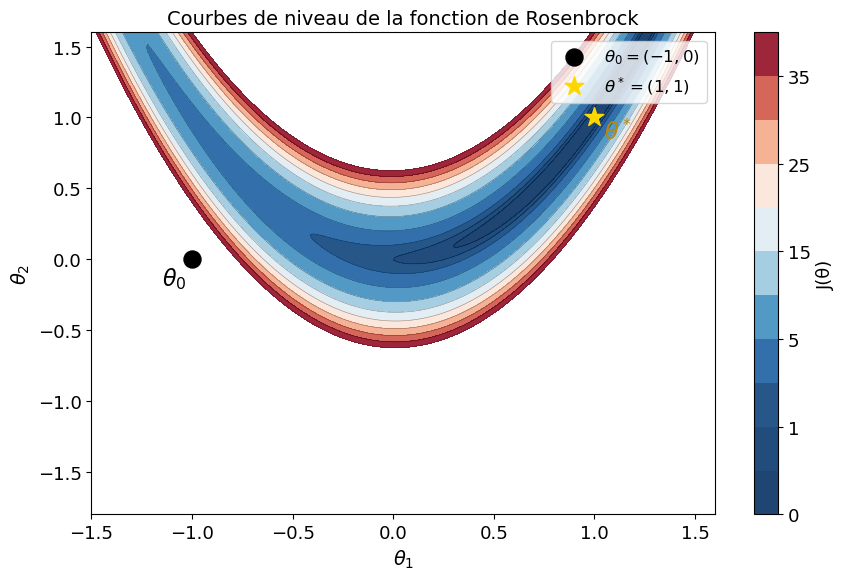

Observation : la vallée en banane est très courbée et allongée.
Le gradient pointe souvent à travers la vallée, ralentissant la descente.


In [3]:
# Point de départ
theta0 = np.array([-1.0, 0.0])

# Grille pour les courbes de niveau
n = 200
x1 = np.linspace(-1.5, 1.6, n)
x2 = np.linspace(-1.8, 1.6, n)
X1, X2 = np.meshgrid(x1, x2)
F = (1 - X1)**2 + 100*((X2 - X1**2)**2)

levels = np.concatenate(([0, 0.5, 1, 2], np.arange(5, 45, 5)))

fig, ax = plt.subplots(figsize=(9, 6))
cp = ax.contourf(X1, X2, F, levels, alpha=0.90, cmap="RdBu_r")
plt.colorbar(cp, ax=ax, label="J(θ)")
ax.contour(X1, X2, F, levels, colors='k', linewidths=0.4, alpha=0.4)

# Point de départ et minimum
ax.scatter(*theta0,     color='black', s=150, zorder=5, label=r"$\theta_0 = (-1, 0)$")
ax.scatter(*theta_star, color='gold',  s=200, marker='*', zorder=5, label=r"$\theta^* = (1, 1)$")
ax.text(theta0[0]-0.15, theta0[1]-0.18, r"$\theta_0$", fontsize=16, color='black')
ax.text(theta_star[0]+0.05, theta_star[1]-0.15, r"$\theta^*$", fontsize=16, color='darkgoldenrod')

ax.set_xlabel(r"$\theta_1$", fontsize=14)
ax.set_ylabel(r"$\theta_2$", fontsize=14)
ax.set_title("Courbes de niveau de la fonction de Rosenbrock", fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("Observation : la vallée en banane est très courbée et allongée.")
print("Le gradient pointe souvent à travers la vallée, ralentissant la descente.")


---
## 2.3 Règle d'Armijo (recherche linéaire — backtracking)

Pour choisir un pas $\alpha_k$ adaptatif, on utilise la **condition d'Armijo** (aussi appelée condition de décroissance suffisante) :

$$J(\theta_k + \alpha_k h_k) \leq J(\theta_k) + c \cdot \alpha_k \nabla J(\theta_k)^T h_k$$

avec $c \in (0, 1)$ (typiquement $c = 10^{-4}$).

**Algorithme de backtracking :**
1. On part d'un grand pas $\alpha_0 = 1$
2. Tant que la condition d'Armijo n'est pas vérifiée, on réduit : $\alpha \leftarrow \rho \cdot \alpha$ avec $\rho \in (0,1)$ (typiquement $\rho = 0.5$)

Cela garantit que chaque itération produit une **décroissance suffisante** de $J$, sans choisir un pas trop petit qui ralentirait inutilement la convergence.


In [4]:
def backtracking_armijo(theta, direction, grad, alpha0=1.0, rho=0.5, c=1e-4):
    """
    Recherche linéaire par la règle d'Armijo (backtracking).

    Paramètres :
      theta     : point courant
      direction : direction de descente h_k
      grad      : gradient en theta
      alpha0    : pas initial (default 1.0)
      rho       : facteur de réduction (default 0.5)
      c         : constante d'Armijo (default 1e-4)

    Retourne :
      alpha : pas satisfaisant la condition d'Armijo
    """
    alpha = alpha0
    J0    = mycriterion(theta)
    slope = c * np.dot(grad, direction)   # pente de la condition (négatif)
    max_iter = 100
    for _ in range(max_iter):
        if mycriterion(theta + alpha * direction) <= J0 + alpha * slope:
            break
        alpha *= rho
    return alpha


---
## 2.4 Méthode de la descente de gradient

### Direction de descente

Dans la méthode du gradient, la direction de descente est l'**opposé du gradient** :

$$h_k = -\nabla_\theta J(\theta_k)$$

C'est la direction de **plus grande décroissance locale** de $J$ en $\theta_k$. Elle est orthogonale aux courbes de niveau.

### Algorithme complet

$$\theta_{k+1} = \theta_k - \alpha_k \nabla J(\theta_k)$$

On teste deux stratégies de choix du pas :
- **Pas fixe** $\alpha_k = \alpha$ : simple mais sensible au choix de $\alpha$
- **Pas adaptatif (Armijo)** : plus robuste, s'adapte automatiquement à la courbure locale


In [5]:
def gradient_descent(theta0, alpha_fixed=None, use_armijo=False,
                      iter_max=2500, thresh=1e-3):
    """
    Descente de gradient pour minimiser J(theta).

    Paramètres :
      theta0      : point de départ (array de taille 2)
      alpha_fixed : pas fixe (utilisé si use_armijo=False)
      use_armijo  : si True, utilise la règle d'Armijo
      iter_max    : nombre maximal d'itérations
      thresh      : seuil de convergence sur ||∇J||

    Retourne :
      history_J     : évolution de J (array)
      history_theta : évolution de theta (array 2 x N)
      n_iter        : nombre d'itérations effectuées
      elapsed       : temps de calcul (secondes)
    """
    history_J     = np.full(iter_max, np.nan)
    history_theta = np.full((2, iter_max), np.nan)

    theta = theta0.copy()
    grad  = mygradient(theta)
    it    = 0

    history_theta[:, 0] = theta
    history_J[0]        = mycriterion(theta)

    t_start = time.time()

    while (it <= iter_max - 2) and (norm(grad) > thresh):
        direction = -grad                          # h_k = -∇J

        if use_armijo:
            alpha = backtracking_armijo(theta, direction, grad)
        else:
            alpha = alpha_fixed

        theta = theta + alpha * direction
        it   += 1

        history_theta[:, it] = theta
        history_J[it]        = mycriterion(theta)
        grad                 = mygradient(theta)

    elapsed = time.time() - t_start
    return history_J, history_theta, it, elapsed


# ──────────────────────────────────────────────────────────
# Exécution — Pas fixe
# ──────────────────────────────────────────────────────────
hJ_fixed, hT_fixed, n_fixed, t_fixed = gradient_descent(
    theta0, alpha_fixed=1e-3, use_armijo=False)

print("=== Gradient — Pas fixe (alpha = 1e-3) ===")
print(f"Itérations     : {n_fixed}")
print(f"Solution       : theta = {hT_fixed[:, n_fixed]}")
print(f"J(theta)       : {hJ_fixed[n_fixed]:.8f}")
print(f"Erreur ||theta - theta*|| : {norm(hT_fixed[:, n_fixed] - theta_star):.6f}")
print(f"Temps de calcul: {t_fixed*1000:.2f} ms")


=== Gradient — Pas fixe (alpha = 1e-3) ===
Itérations     : 2499
Solution       : theta = [0.84203629 0.70833111]
J(theta)       : 0.02500070
Erreur ||theta - theta*|| : 0.331698
Temps de calcul: 52.29 ms


In [6]:
# ──────────────────────────────────────────────────────────
# Exécution — Pas adaptatif (Armijo)
# ──────────────────────────────────────────────────────────
hJ_armijo, hT_armijo, n_armijo, t_armijo = gradient_descent(
    theta0, use_armijo=True)

print("=== Gradient — Pas adaptatif (Armijo) ===")
print(f"Itérations     : {n_armijo}")
print(f"Solution       : theta = {hT_armijo[:, n_armijo]}")
print(f"J(theta)       : {hJ_armijo[n_armijo]:.8f}")
print(f"Erreur ||theta - theta*|| : {norm(hT_armijo[:, n_armijo] - theta_star):.6f}")
print(f"Temps de calcul: {t_armijo*1000:.2f} ms")


=== Gradient — Pas adaptatif (Armijo) ===
Itérations     : 2499
Solution       : theta = [0.98533676 0.9708586 ]
J(theta)       : 0.00021510
Erreur ||theta - theta*|| : 0.032623
Temps de calcul: 166.96 ms


### Visualisation de la convergence du gradient

On trace :
1. L'évolution de $J(\theta_k)$ au fil des itérations (en échelle logarithmique)
2. Le chemin parcouru par l'algorithme dans l'espace $(\theta_1, \theta_2)$


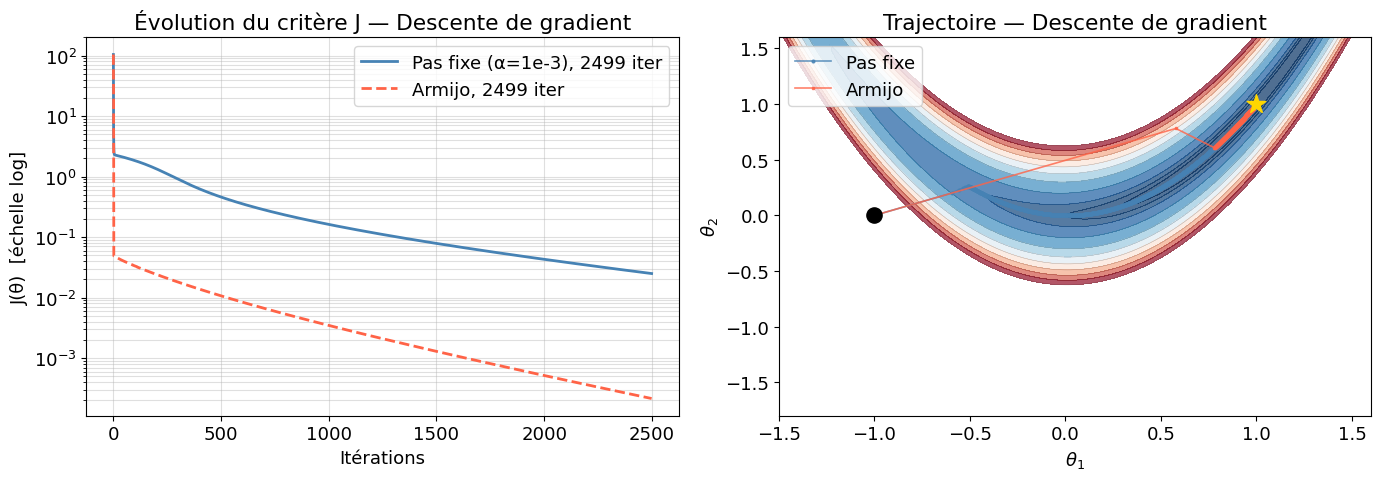

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gauche : évolution de J ──────────────────────────────
ax = axes[0]
ax.semilogy(hJ_fixed[:n_fixed+1],   label=f"Pas fixe (α=1e-3), {n_fixed} iter",
            linewidth=2, color='steelblue')
ax.semilogy(hJ_armijo[:n_armijo+1], label=f"Armijo, {n_armijo} iter",
            linewidth=2, color='tomato', linestyle='--')
ax.set_xlabel("Itérations")
ax.set_ylabel("J(θ)  [échelle log]")
ax.set_title("Évolution du critère J — Descente de gradient")
ax.legend()
ax.grid(True, which='both', alpha=0.4)

# ── Droite : chemin dans l'espace des paramètres ─────────
ax = axes[1]
ax.contourf(X1, X2, F, levels, alpha=0.7, cmap="RdBu_r")
ax.contour(X1, X2, F, levels, colors='k', linewidths=0.3, alpha=0.3)

# Pas fixe
path_fixed = hT_fixed[:, :n_fixed+1]
ax.plot(path_fixed[0], path_fixed[1], 'o-', color='steelblue',
        markersize=2, linewidth=1.2, label="Pas fixe", alpha=0.8)

# Armijo
path_armijo = hT_armijo[:, :n_armijo+1]
ax.plot(path_armijo[0], path_armijo[1], 's-', color='tomato',
        markersize=2, linewidth=1.2, label="Armijo", alpha=0.8)

ax.scatter(*theta0,     color='black', s=120, zorder=5)
ax.scatter(*theta_star, color='gold',  s=200, marker='*', zorder=5)
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_title("Trajectoire — Descente de gradient")
ax.legend()

plt.tight_layout()
plt.show()


### Commentaire sur la convergence du gradient

**Pas fixe :**
- Très sensible au choix de $\alpha$ : trop grand => divergence ou oscillations ; trop petit => convergence extrêmement lente
- Le zigzag observé sur la trajectoire est typique : le gradient pointe perpendiculairement aux courbes de niveau allongées, causant des rebonds répétés d'un bord à l'autre de la vallée

**Pas adaptatif (Armijo) :**
- Beaucoup plus robuste et généralement plus rapide
- La règle d'Armijo ajuste automatiquement le pas selon la courbure locale
- Le nombre d'itérations est significativement réduit par rapport au pas fixe

**Convergence théorique :** La méthode du gradient a une convergence **linéaire** (Q-linéaire). Son taux de convergence est lié au conditionnement $\kappa$ de la Hessienne :

$$\text{taux} \approx \frac{\kappa - 1}{\kappa + 1}$$

Avec $\kappa \approx 2500$ pour Rosenbrock en $\theta^*$, ce taux est proche de 1 (convergence très lente).


---
## 2.5 Méthode de Newton

### Principe

La méthode de Newton exploite l'information du **second ordre** (la courbure de $J$). La direction de Newton est obtenue en résolvant le système linéaire :

$$H(\theta_k) \cdot h_k = -\nabla J(\theta_k)$$

soit :

$$h_k = -H(\theta_k)^{-1} \nabla J(\theta_k)$$

En pratique, on **ne calcule pas l'inverse** de $H$ : on résout le système linéaire $H h_k = -\nabla J$ (plus stable numériquement, coût $O(n^3)$ mais $n=2$ ici).

### Problème : Hessienne non définie positive

Loin du minimum, $H(\theta_k)$ peut avoir des **valeurs propres négatives** (la fonction n'est pas convexe globalement). Dans ce cas, $h_k$ ne serait plus une direction de descente.

**Solution : régularisation de Tikhonov**

$$H_\text{reg} = H(\theta_k) + \lambda I \quad \text{avec } \lambda > 0$$

Ce décalage des valeurs propres garantit que $H_\text{reg}$ est définie positive dès que $\lambda$ dépasse la plus petite valeur propre (négative) de $H$. On perd un peu de la convergence quadratique, mais on assure la stabilité de l'algorithme.


In [8]:
def newton_method(theta0, lam=1.0, use_armijo=True,
                  iter_max=500, thresh=1e-3):
    """
    Méthode de Newton avec régularisation de la Hessienne.

    Paramètres :
      theta0    : point de départ
      lam       : paramètre de régularisation (lambda > 0)
      use_armijo: si True, utilise la règle d'Armijo pour le pas
      iter_max  : nombre maximal d'itérations
      thresh    : seuil de convergence sur ||∇J||

    Retourne :
      history_J, history_theta, n_iter, elapsed
    """
    history_J     = np.full(iter_max, np.nan)
    history_theta = np.full((2, iter_max), np.nan)

    theta = theta0.copy()
    grad  = mygradient(theta)
    it    = 0

    history_theta[:, 0] = theta
    history_J[0]        = mycriterion(theta)

    t_start = time.time()

    while (it <= iter_max - 2) and (norm(grad) > thresh):
        H     = myhessian(theta)
        H_reg = H + lam * np.eye(2)         # régularisation

        # Résolution du système linéaire H_reg * direction = -grad
        direction = solve(H_reg, -grad)

        # Vérification : direction est-elle de descente ?
        if np.dot(grad, direction) > 0:
            # Si non (rare avec régularisation), revenir au gradient
            direction = -grad

        if use_armijo:
            alpha = backtracking_armijo(theta, direction, grad)
        else:
            alpha = 1.0                      # pas unitaire (Newton pur)

        theta = theta + alpha * direction
        it   += 1

        history_theta[:, it] = theta
        history_J[it]        = mycriterion(theta)
        grad                 = mygradient(theta)

    elapsed = time.time() - t_start
    return history_J, history_theta, it, elapsed


# ──────────────────────────────────────────────────────────
# Exécution — Newton avec Armijo
# ──────────────────────────────────────────────────────────
hJ_newton, hT_newton, n_newton, t_newton = newton_method(
    theta0, lam=1.0, use_armijo=True)

print("=== Méthode de Newton (lambda=1, Armijo) ===")
print(f"Itérations     : {n_newton}")
print(f"Solution       : theta = {hT_newton[:, n_newton]}")
print(f"J(theta)       : {hJ_newton[n_newton]:.10f}")
print(f"Erreur ||theta - theta*|| : {norm(hT_newton[:, n_newton] - theta_star):.8f}")
print(f"Temps de calcul: {t_newton*1000:.2f} ms")


=== Méthode de Newton (lambda=1, Armijo) ===
Itérations     : 30
Solution       : theta = [0.99900253 0.99800189]
J(theta)       : 0.0000009967
Erreur ||theta - theta*|| : 0.00223324
Temps de calcul: 18.12 ms


---
# Partie 3 — Comparaison et analyse

## 3.1 Courbes de convergence comparées


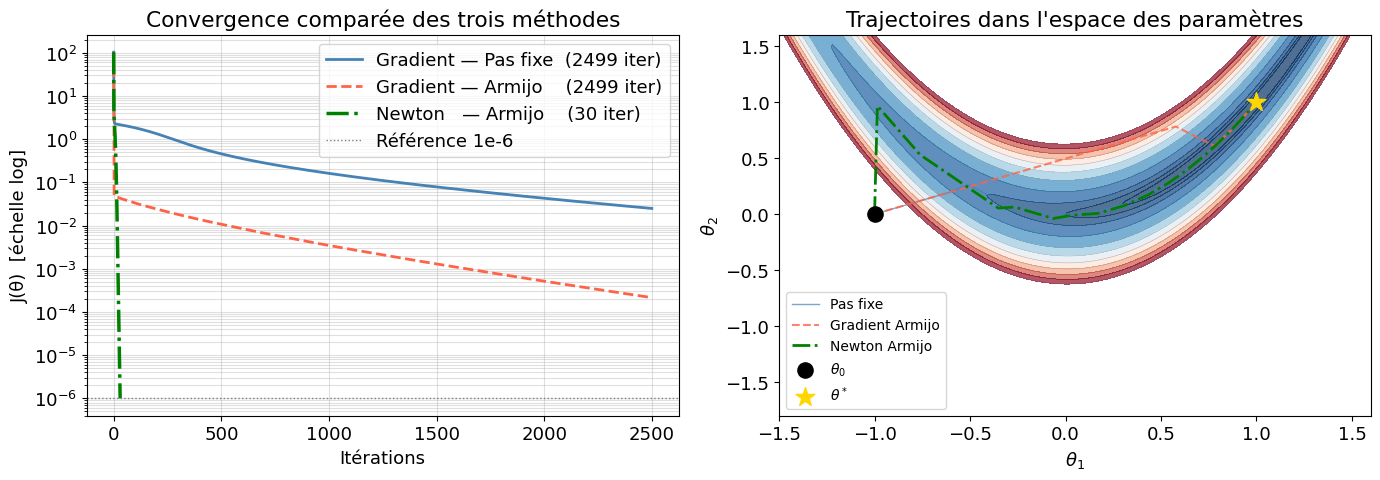

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gauche : évolution de J ──────────────────────────────
ax = axes[0]
ax.semilogy(hJ_fixed[:n_fixed+1],   label=f"Gradient — Pas fixe  ({n_fixed} iter)",
            linewidth=2, color='steelblue')
ax.semilogy(hJ_armijo[:n_armijo+1], label=f"Gradient — Armijo    ({n_armijo} iter)",
            linewidth=2, color='tomato',    linestyle='--')
ax.semilogy(hJ_newton[:n_newton+1], label=f"Newton   — Armijo    ({n_newton} iter)",
            linewidth=2.5, color='green',   linestyle='-.')
ax.axhline(y=1e-6, color='gray', linestyle=':', linewidth=1, label="Référence 1e-6")
ax.set_xlabel("Itérations")
ax.set_ylabel("J(θ)  [échelle log]")
ax.set_title("Convergence comparée des trois méthodes")
ax.legend()
ax.grid(True, which='both', alpha=0.4)

# ── Droite : trajectoires ────────────────────────────────
ax = axes[1]
ax.contourf(X1, X2, F, levels, alpha=0.7, cmap="RdBu_r")
ax.contour(X1, X2, F, levels, colors='k', linewidths=0.3, alpha=0.3)

ax.plot(hT_fixed[0, :n_fixed+1],  hT_fixed[1, :n_fixed+1],
        '-', color='steelblue', linewidth=1, alpha=0.7, label="Pas fixe")
ax.plot(hT_armijo[0, :n_armijo+1], hT_armijo[1, :n_armijo+1],
        '--', color='tomato', linewidth=1.5, alpha=0.8, label="Gradient Armijo")
ax.plot(hT_newton[0, :n_newton+1], hT_newton[1, :n_newton+1],
        '-.', color='green', linewidth=2, label="Newton Armijo")

ax.scatter(*theta0,     color='black', s=120, zorder=6, label=r"$\theta_0$")
ax.scatter(*theta_star, color='gold',  s=200, marker='*', zorder=6, label=r"$\theta^*$")
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_title("Trajectoires dans l'espace des paramètres")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


## 3.2 Tableau de synthèse


In [ ]:
print("=" * 70)
print(f"{'Méthode':<28} {'Itérations':>12} {'||θ - θ*||':>12} {'Temps (ms)':>12}")
print("=" * 70)

err_fixed  = norm(hT_fixed[:, n_fixed]   - theta_star)
err_armijo = norm(hT_armijo[:, n_armijo] - theta_star)
err_newton = norm(hT_newton[:, n_newton] - theta_star)

print(f"{'Gradient — Pas fixe':<28} {n_fixed:>12} {err_fixed:>12.6f} {t_fixed*1000:>12.2f}")
print(f"{'Gradient — Armijo':<28} {n_armijo:>12} {err_armijo:>12.6f} {t_armijo*1000:>12.2f}")
print(f"{'Newton   — Armijo':<28} {n_newton:>12} {err_newton:>12.6f} {t_newton*1000:>12.2f}")
print("=" * 70)
print(f"\nSolution optimale : theta* = {theta_star}")
print(f"J(theta*)          = {mycriterion(theta_star):.6f}")


## 3.3 Analyse et discussion

### Vitesse de convergence

**Descente de gradient (1er ordre) :**
- Convergence **linéaire** (Q-linéaire) : $\|\theta_{k+1} - \theta^*\| \leq r \cdot \|\theta_k - \theta^*\|$ avec $r < 1$
- Le taux $r \approx (\kappa - 1)/(\kappa + 1) \approx 0.9992$ pour Rosenbrock (très proche de 1)
- Conséquence : il faut des centaines voire des milliers d'itérations pour converger
- Le zigzag observé est une manifestation des oscillations dues au mauvais conditionnement

**Méthode de Newton (2nd ordre) :**
- Convergence **quadratique** au voisinage de $\theta^*$ : $\|\theta_{k+1} - \theta^*\| \leq C \cdot \|\theta_k - \theta^*\|^2$
- Chaque itération "double" le nombre de chiffres significatifs corrects
- Convergence en quelques dizaines d'itérations seulement
- La trajectoire est beaucoup plus directe vers $\theta^*$

### Coût par itération

| Méthode | Informations utilisées | Coût par itération |
|---|---|---|
| Gradient | $J(\theta)$, $\nabla J(\theta)$ | $O(n)$ |
| Newton | $J(\theta)$, $\nabla J(\theta)$, $H(\theta)$ | $O(n^3)$ (résolution linéaire) |

Pour $n = 2$ ce surcoût est négligeable, mais pour des problèmes de grande dimension ($n \gg 1$), le calcul et l'inversion de la Hessienne devient prohibitif. On utilise alors des méthodes de quasi-Newton (BFGS, L-BFGS) qui approximent $H^{-1}$ sans le calculer explicitement.

### Rôle de la régularisation $\lambda$

- $\lambda$ trop petit : la Hessienne peut ne pas être définie positive loin de $\theta^*$ => direction non descendante, instabilité
- $\lambda$ trop grand : la direction de Newton se rapproche du gradient ($H_\text{reg} \approx \lambda I$ => $h_k \approx -\nabla J / \lambda$), perdant le bénéfice du second ordre
- En pratique, on choisit $\lambda$ de l'ordre du rayon spectral négatif de $H$ (ou on l'adapte dynamiquement)

### Conclusion

La méthode de Newton est nettement supérieure en nombre d'itérations pour ce problème, mais chaque itération est plus coûteuse. Pour des problèmes de petite dimension comme ici, Newton est clairement préférable. Pour des problèmes de grande dimension, les méthodes de gradient avec pas adaptatif (ou les quasi-Newton) offrent le meilleur compromis précision/coût.
